In [1]:
# ============================================
# EXPLORATORY DATA ANALYSIS (EDA)
# Dataset : data_collect_from_bidan_fix.xlsx
# Tujuan  : Analisis kualitas & karakteristik data
# Catatan : BELUM preprocessing & BELUM modeling
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [2]:
df = pd.read_excel("data_collect_from_bidan_fix.xlsx")

df.head()


,usia,bmi,sistolik,diastolik,proteinuria,diabetes,hb,berat_janin,cairan_ketuban,riwayat_hipertensi,riwayat_keluarga,primigravida,kehamilan_kembar,diagnosis_lanjutan
0,31,33.3,121,84,negatif,tidak,10.9,3.2,8.6,iya,tidak,tidak,tidak,Tidak
1,38,20.2,138,62,+,iya,9.6,2.3,19.2,tidak,tidak,iya,tidak,Preeklamsia
2,36,23.4,135,84,negatif,iya,9.9,4.5,15.5,tidak,tidak,tidak,tidak,Preeklamsia
3,39,29.0,120,77,negatif,tidak,12.6,2.3,15.6,tidak,iya,tidak,tidak,Tidak
4,23,24.0,126,109,negatif,iya,9.4,3.2,8.7,tidak,tidak,iya,tidak,Preeklamsia


In [17]:
print("Total baris:", len(df))
df.tail(5)


Total baris: 457


,usia,bmi,sistolik,diastolik,proteinuria,diabetes,hb,berat_janin,cairan_ketuban,riwayat_hipertensi,riwayat_keluarga,primigravida,kehamilan_kembar,diagnosis_lanjutan
452,23.0,19.8,106.0,94.0,negatif,iya,10.2,3.2,16.0,tidak,tidak,tidak,tidak,Tidak
453,23.0,21.6,126.0,91.0,+,tidak,9.8,3.5,8.0,tidak,tidak,tidak,iya,Preeklamsia
454,23.0,23.9,136.0,70.0,+,iya,11.4,3.9,15.4,iya,tidak,iya,tidak,Preeklamsia
455,27.0,32.8,98.0,80.0,negatif,tidak,12.0,3.4,12.2,tidak,tidak,tidak,tidak,Tidak
456,23.0,30.5,132.0,86.0,negatif,tidak,10.9,3.5,16.2,tidak,tidak,iya,tidak,Preeklamsia


In [16]:
print("Total baris dataset:", len(df))


Total baris dataset: 457


In [3]:
print("Jumlah baris dan kolom :", df.shape)
print("\nStruktur data:")
df.info()


Jumlah baris dan kolom : (457, 14)

Struktur data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   usia                457 non-null    int64  
 1   bmi                 457 non-null    float64
 2   sistolik            457 non-null    int64  
 3   diastolik           457 non-null    int64  
 4   proteinuria         457 non-null    object 
 5   diabetes            457 non-null    object 
 6   hb                  457 non-null    float64
 7   berat_janin         457 non-null    float64
 8   cairan_ketuban      457 non-null    float64
 9   riwayat_hipertensi  457 non-null    object 
 10  riwayat_keluarga    457 non-null    object 
 11  primigravida        457 non-null    object 
 12  kehamilan_kembar    457 non-null    object 
 13  diagnosis_lanjutan  457 non-null    object 
dtypes: float64(4), int64(3), object(7)
memory usage: 50.1+ 

In [4]:
kolom_numerik = [
    "usia", "bmi", "sistolik", "diastolik",
    "hb", "berat_janin", "cairan_ketuban"
]

for col in kolom_numerik:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )


In [5]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Value": missing,
    "Persentase (%)": missing_percent
})


,Missing Value,Persentase (%)
usia,0,0.0
bmi,0,0.0
sistolik,0,0.0
diastolik,0,0.0
proteinuria,0,0.0
diabetes,0,0.0
hb,0,0.0
berat_janin,0,0.0
cairan_ketuban,0,0.0
riwayat_hipertensi,0,0.0


In [6]:
df[kolom_numerik].describe()


,usia,bmi,sistolik,diastolik,hb,berat_janin,cairan_ketuban
count,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000
mean,30.422319,25.083589,120.380744,80.277899,11.377724,3.271554,12.038731
std,7.436499,4.693376,13.739569,11.543748,1.378145,0.774045,4.144867
min,18.000000,17.400000,95.000000,60.000000,9.000000,1.800000,5.100000
25%,23.000000,21.400000,110.000000,71.000000,10.100000,2.600000,8.300000
50%,30.000000,24.300000,120.000000,81.000000,11.300000,3.400000,12.000000
75%,36.000000,28.600000,131.000000,89.000000,12.400000,3.900000,15.300000
max,44.000000,34.800000,164.000000,109.000000,14.000000,4.500000,20.000000


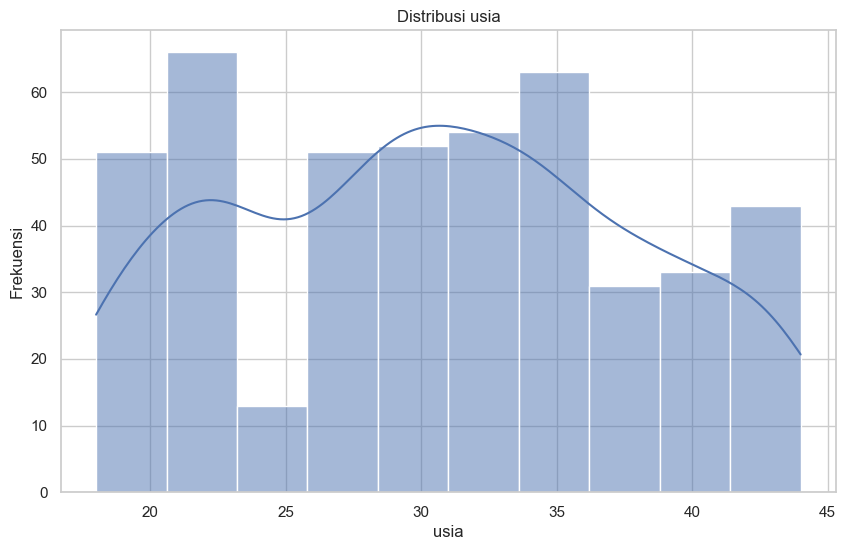

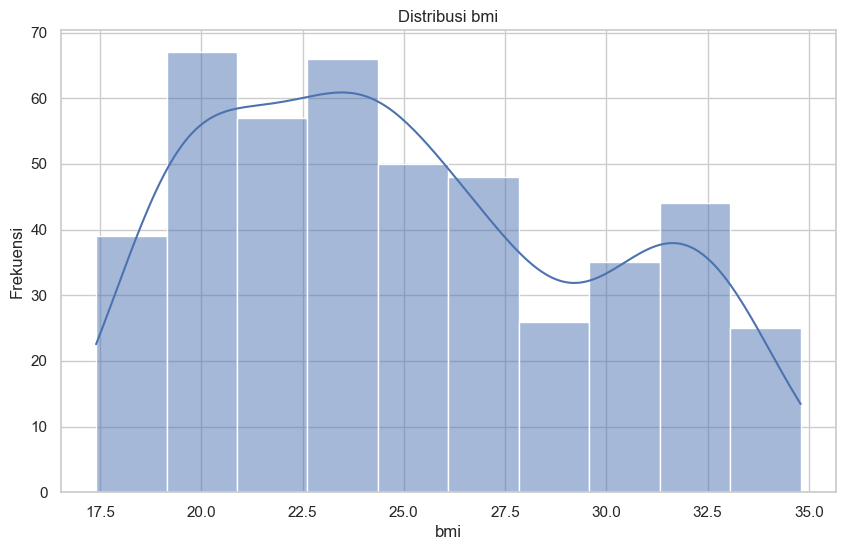

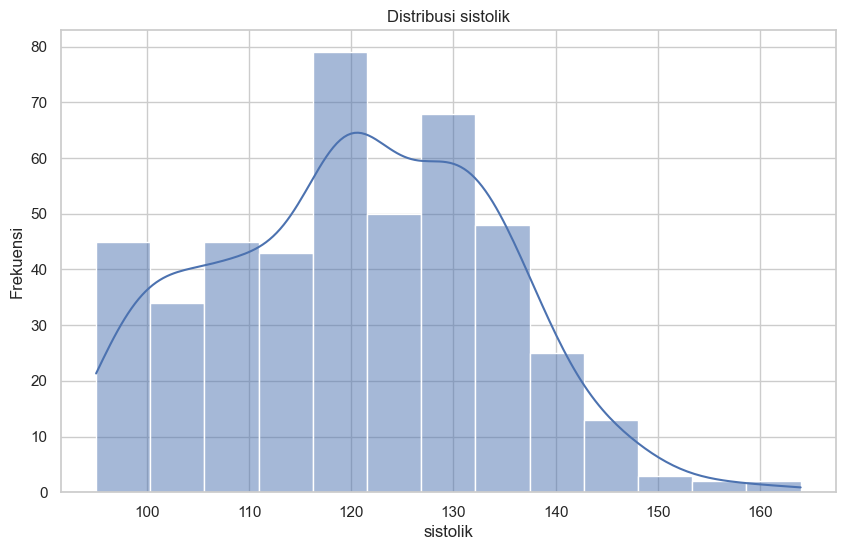

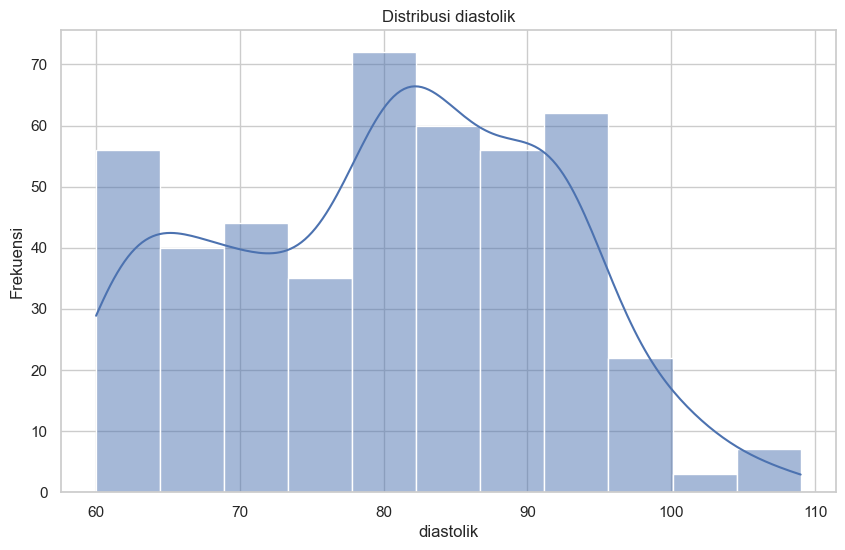

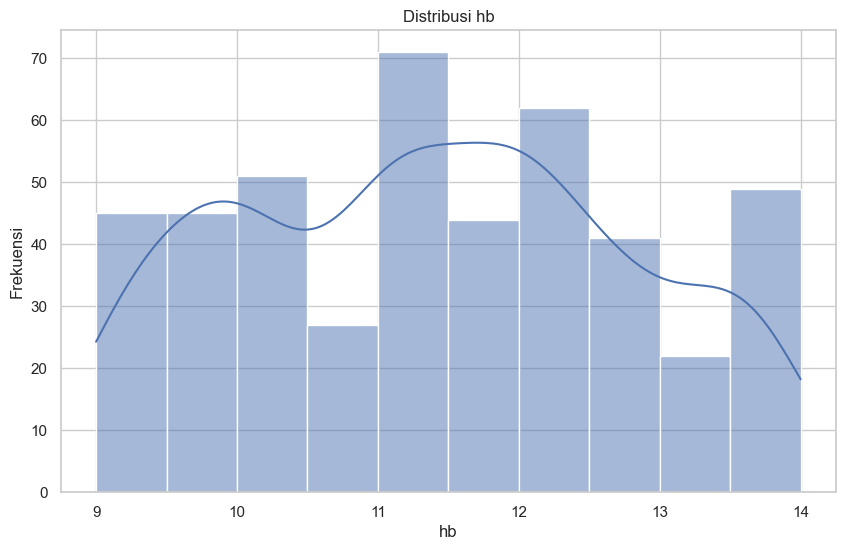

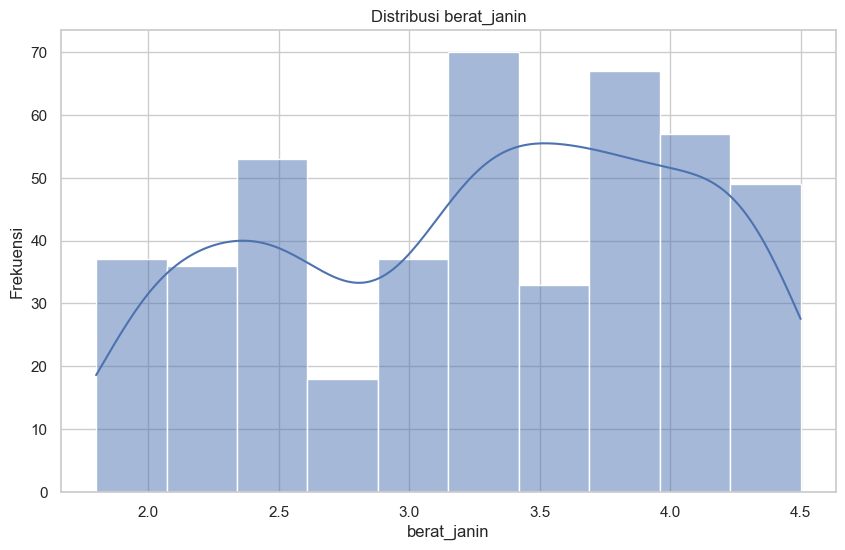

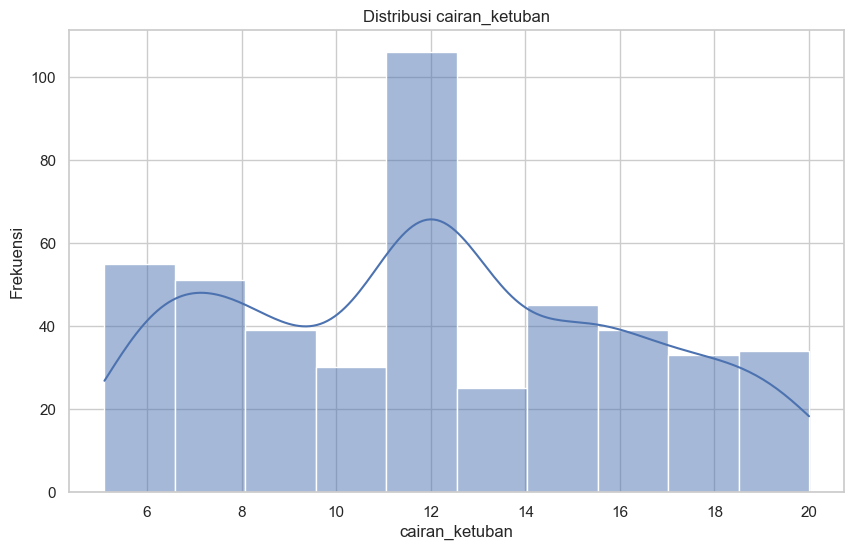

In [7]:
for col in kolom_numerik:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.show()


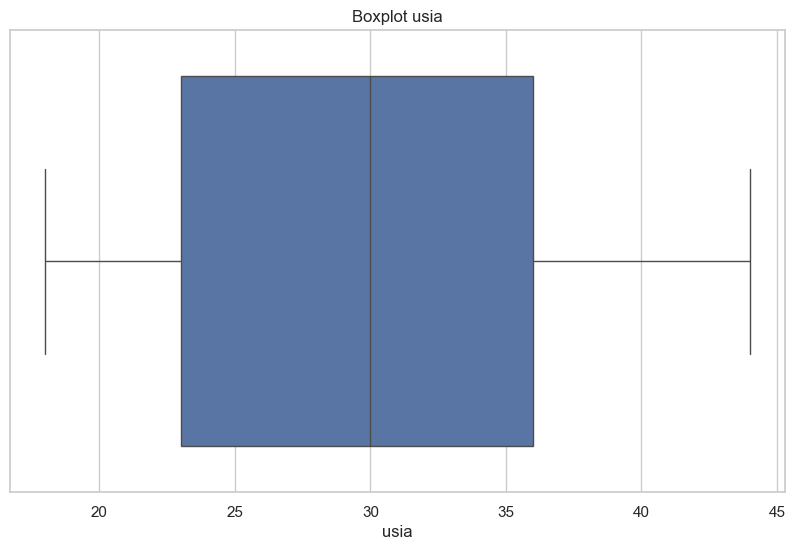

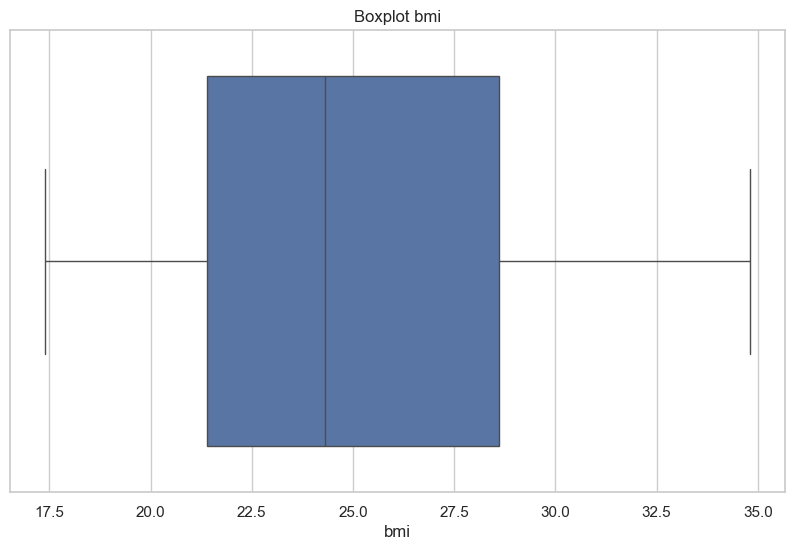

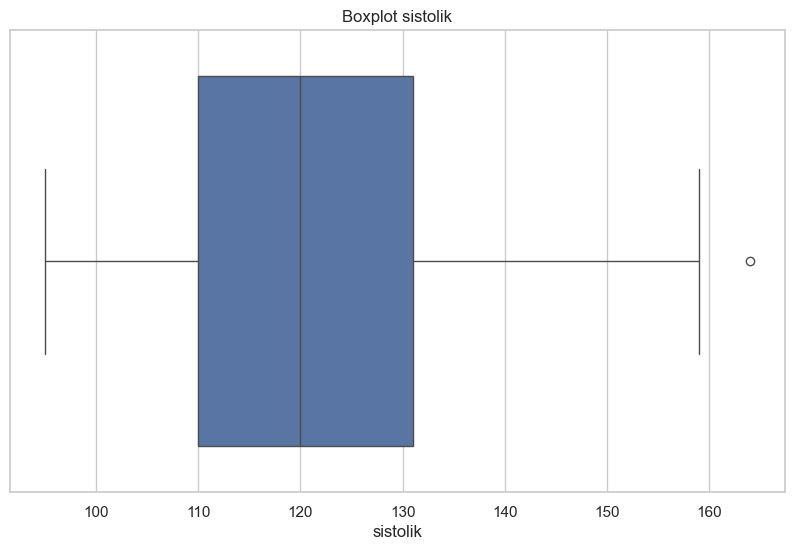

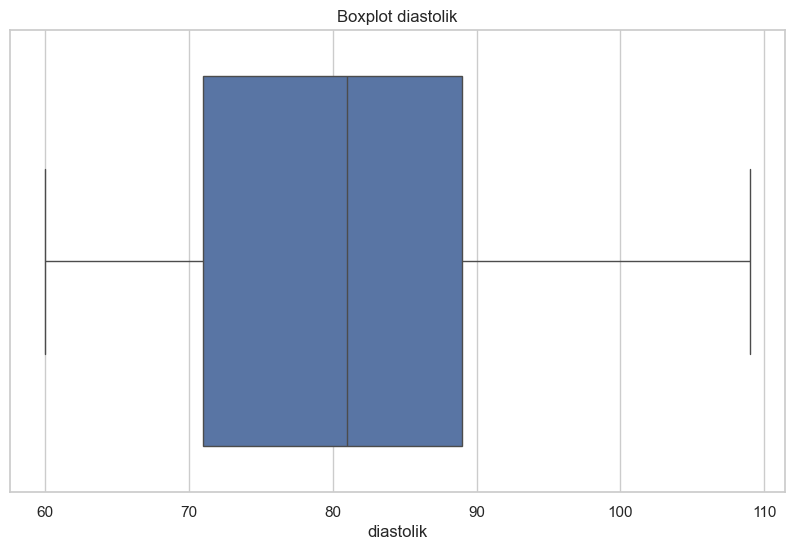

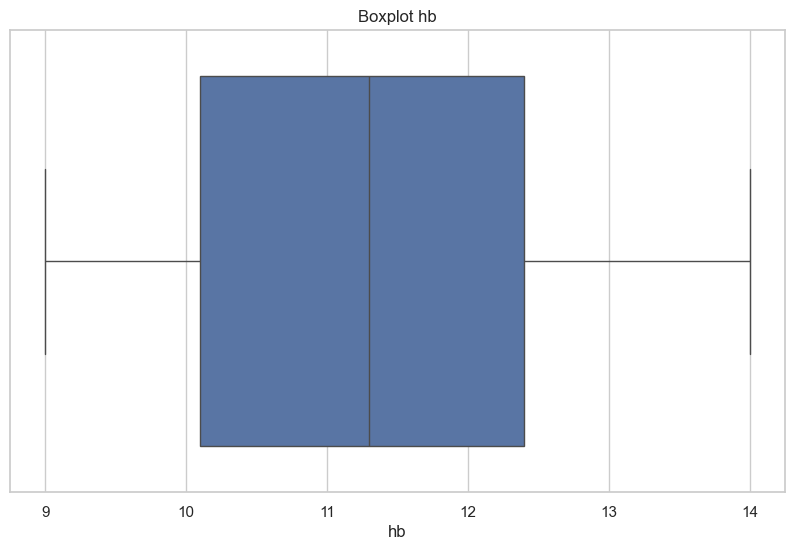

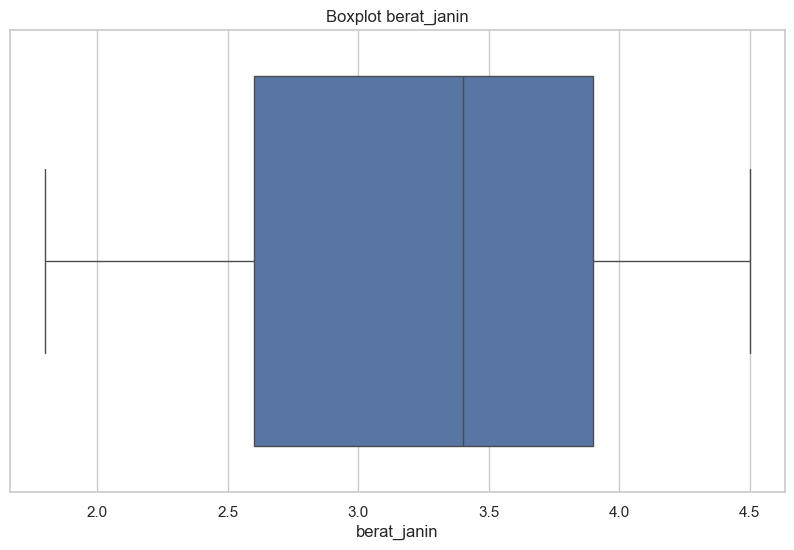

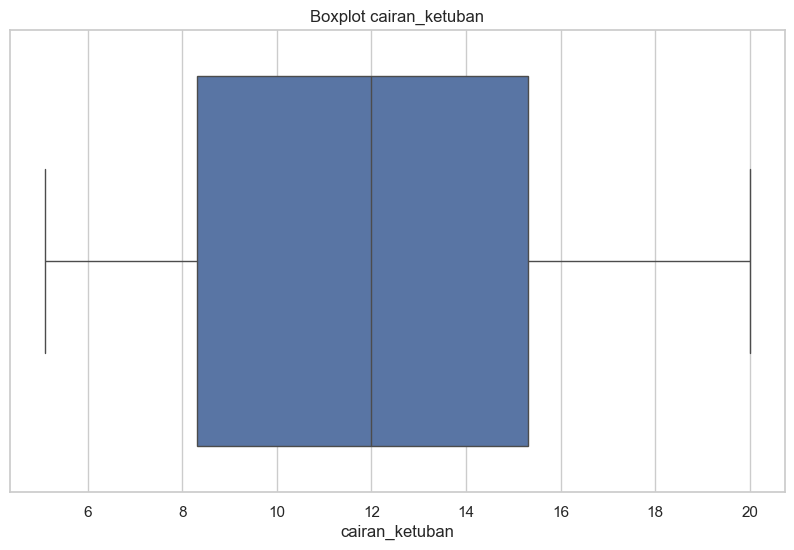

In [8]:
for col in kolom_numerik:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col}")
    plt.show()


In [9]:
kolom_kategorikal = [
    "proteinuria",
    "diabetes",
    "riwayat_hipertensi",
    "riwayat_keluarga",
    "primigravida",
    "kehamilan_kembar",
    "diagnosis_lanjutan"
]

for col in kolom_kategorikal:
    print(f"\nDistribusi {col}")
    print(df[col].value_counts())



Distribusi proteinuria
proteinuria
negatif    415
+           25
++          14
+++          3
Name: count, dtype: int64

Distribusi diabetes
diabetes
tidak    346
iya      111
Name: count, dtype: int64

Distribusi riwayat_hipertensi
riwayat_hipertensi
tidak    329
iya      128
Name: count, dtype: int64

Distribusi riwayat_keluarga
riwayat_keluarga
tidak    357
iya      100
Name: count, dtype: int64

Distribusi primigravida
primigravida
tidak    238
iya      219
Name: count, dtype: int64

Distribusi kehamilan_kembar
kehamilan_kembar
tidak    399
iya       58
Name: count, dtype: int64

Distribusi diagnosis_lanjutan
diagnosis_lanjutan
Tidak          274
Preeklamsia    182
TIdak            1
Name: count, dtype: int64


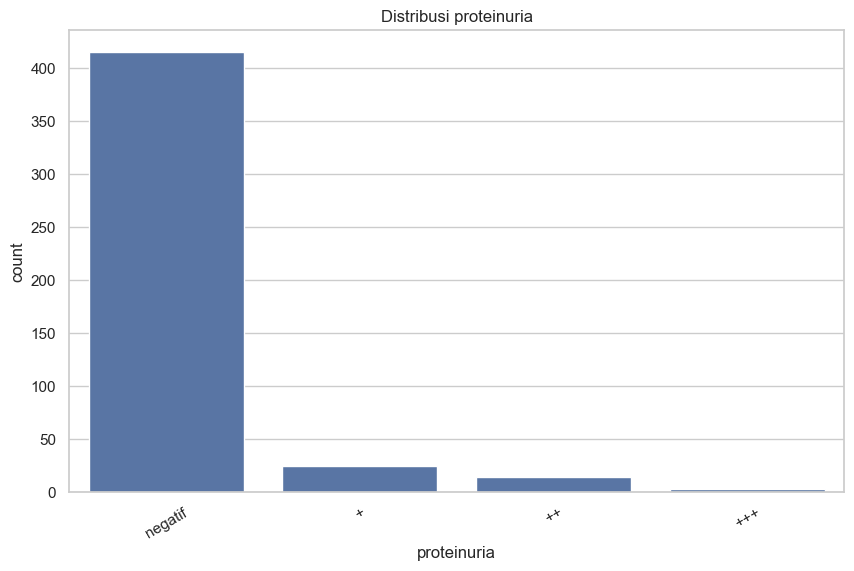

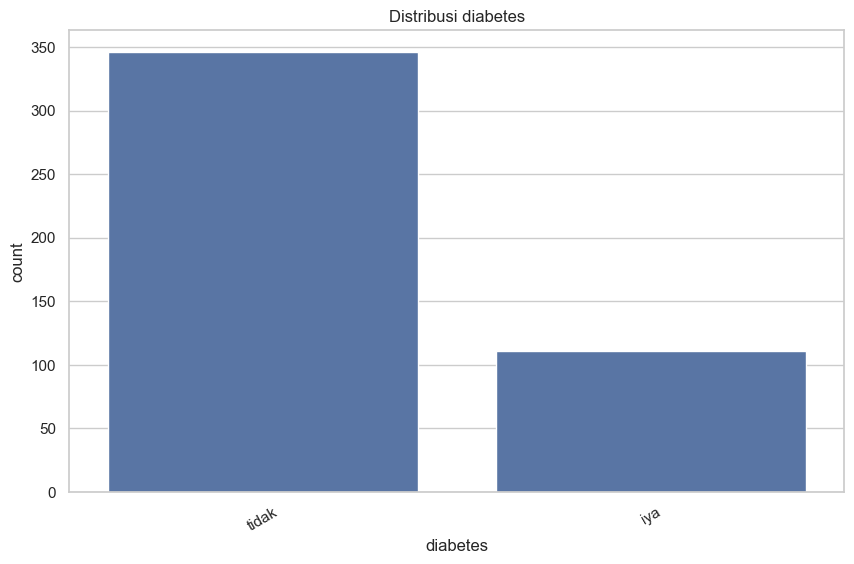

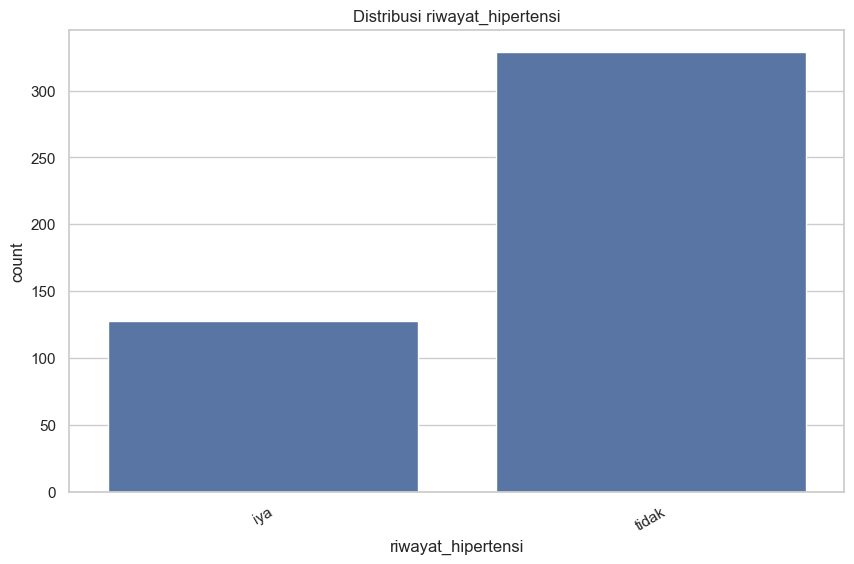

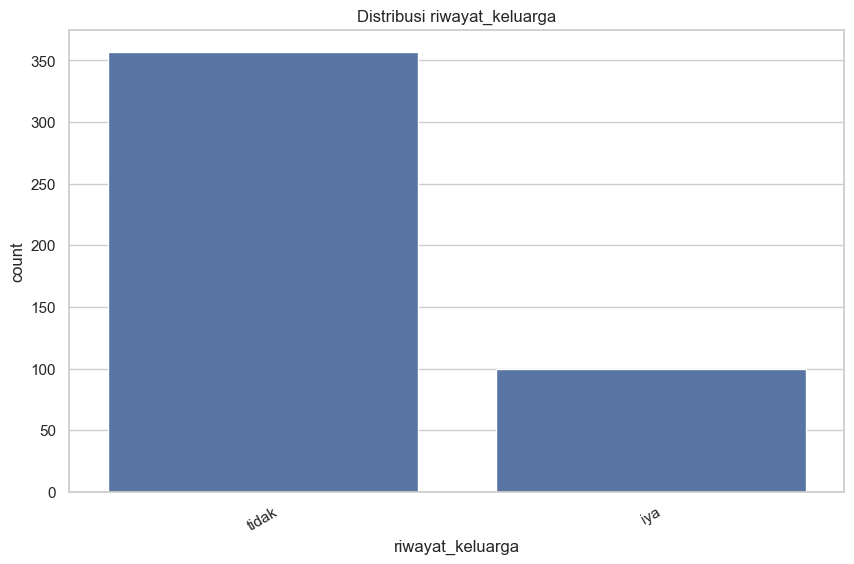

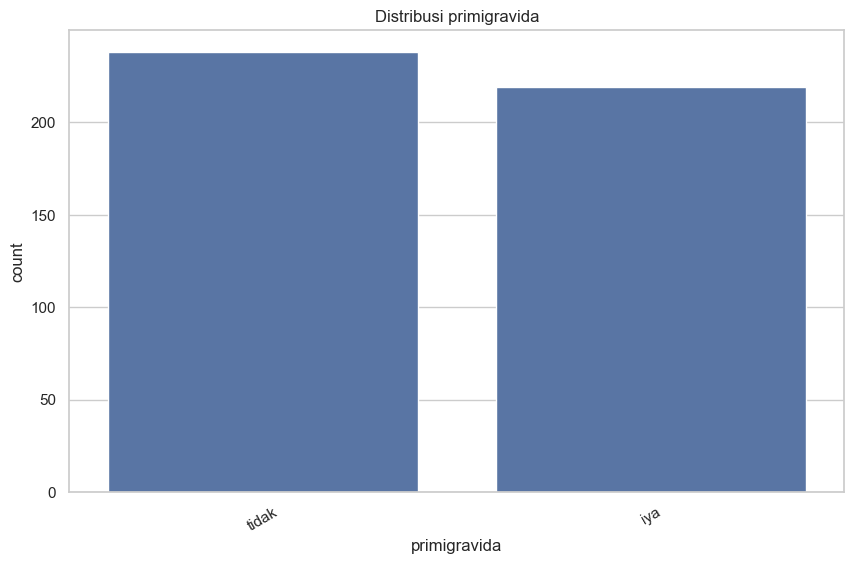

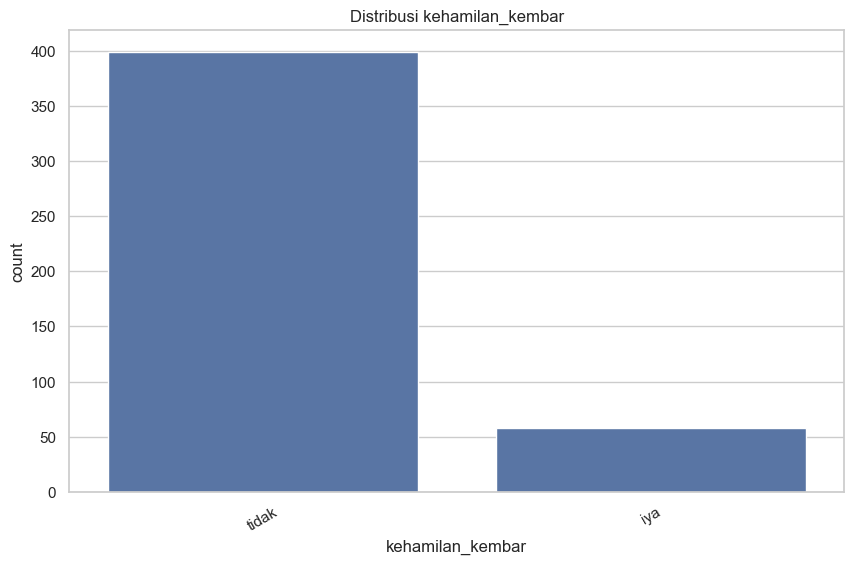

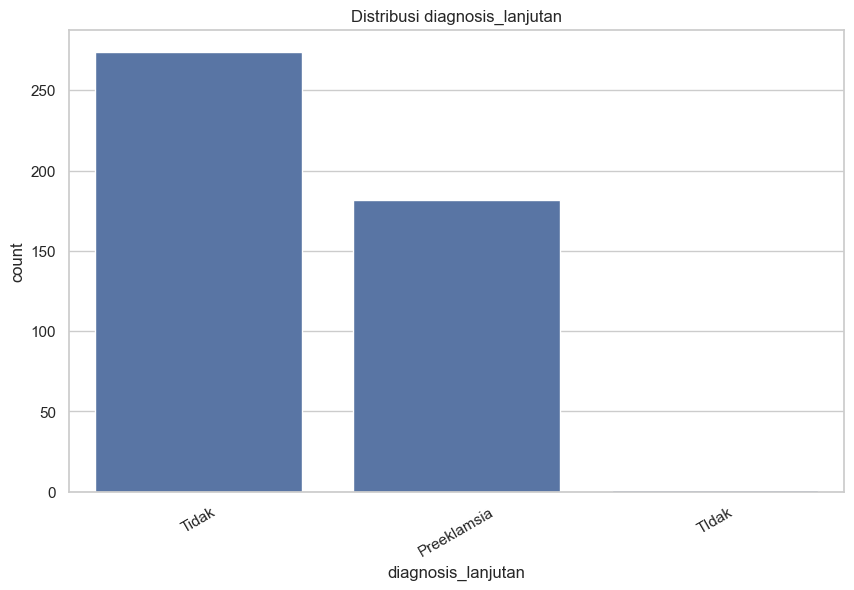

In [10]:
for col in kolom_kategorikal:
    plt.figure()
    sns.countplot(data=df, x=col)
    plt.title(f"Distribusi {col}")
    plt.xticks(rotation=30)
    plt.show()


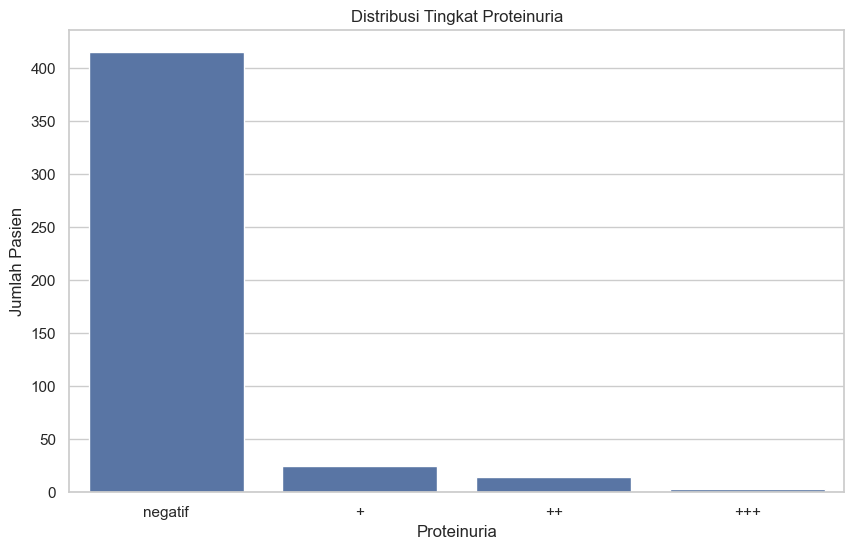

In [11]:
plt.figure()
sns.countplot(
    data=df,
    x="proteinuria",
    order=["negatif", "+", "++", "+++"]
)
plt.title("Distribusi Tingkat Proteinuria")
plt.xlabel("Proteinuria")
plt.ylabel("Jumlah Pasien")
plt.show()


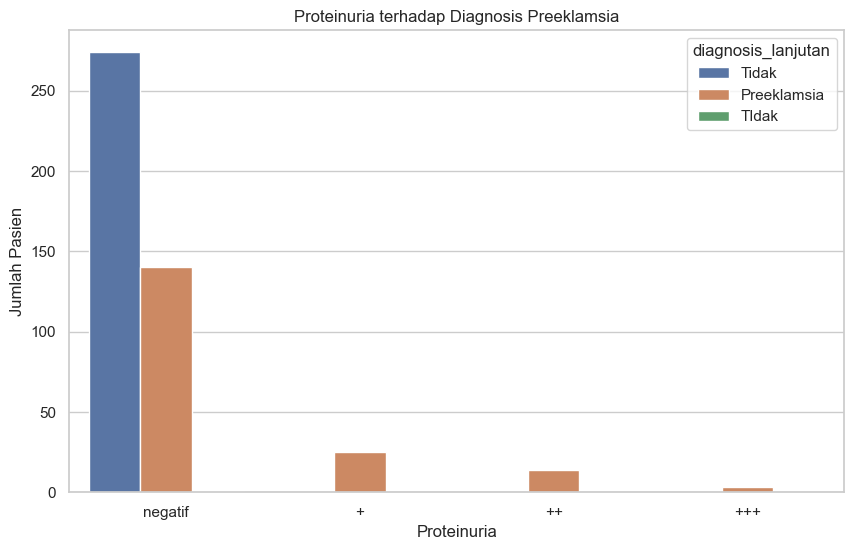

In [12]:
plt.figure()
sns.countplot(
    data=df,
    x="proteinuria",
    hue="diagnosis_lanjutan",
    order=["negatif", "+", "++", "+++"]
)
plt.title("Proteinuria terhadap Diagnosis Preeklamsia")
plt.xlabel("Proteinuria")
plt.ylabel("Jumlah Pasien")
plt.show()


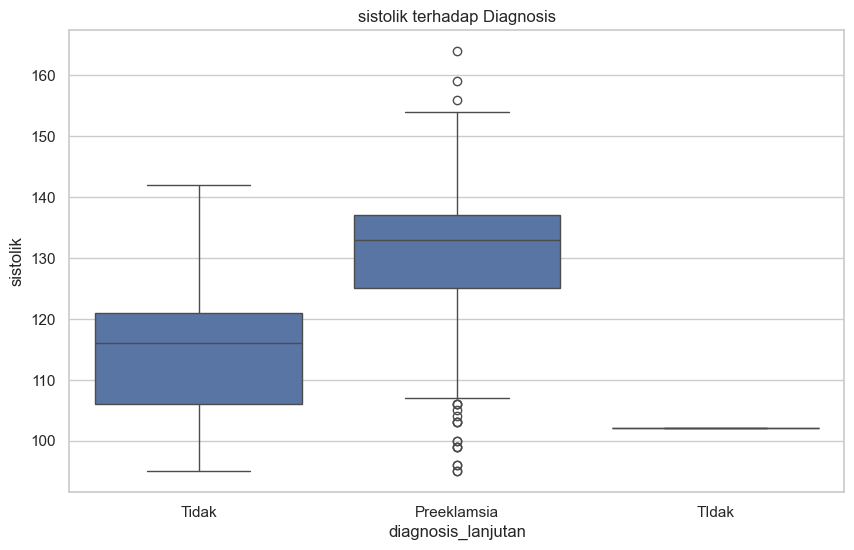

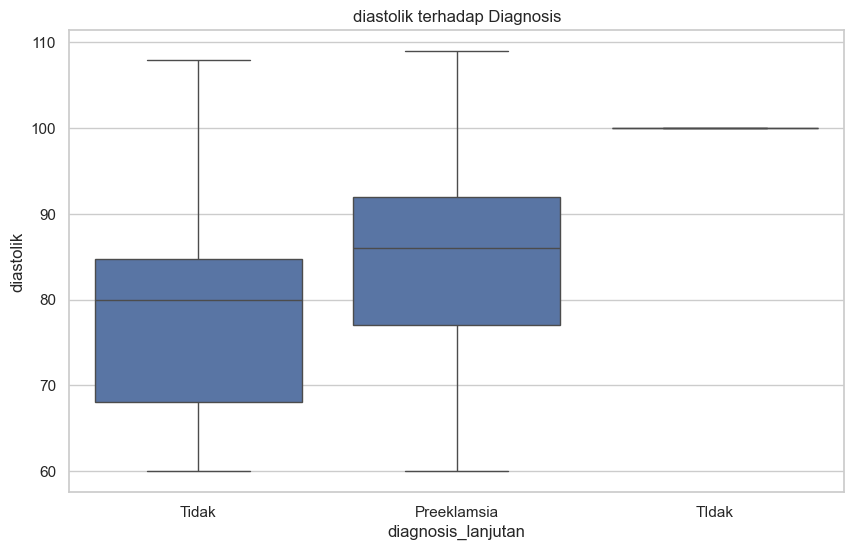

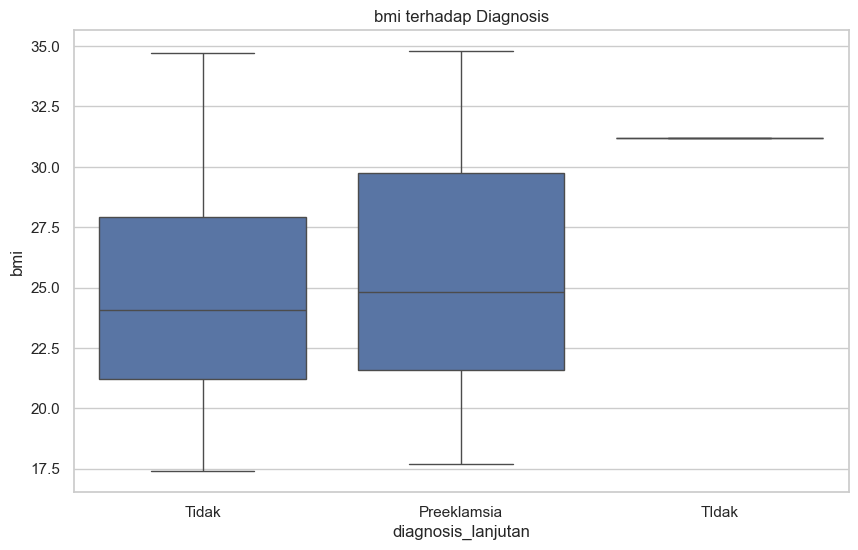

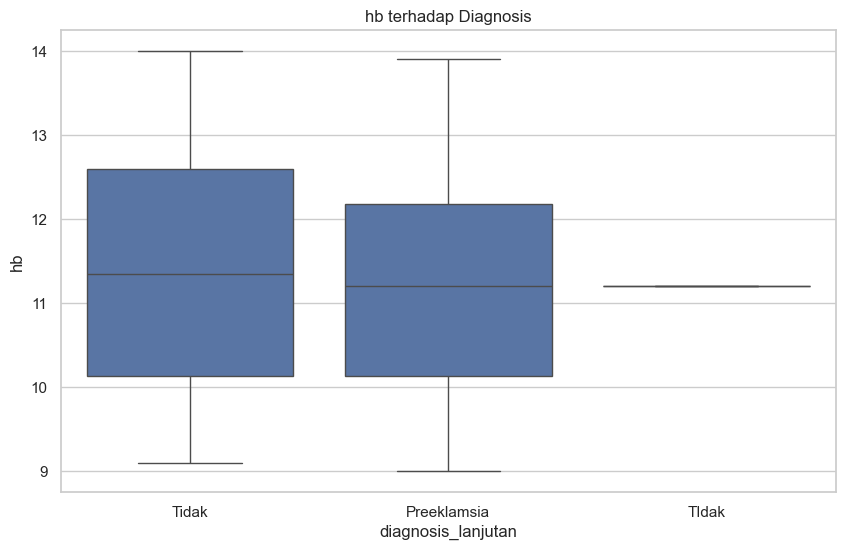

In [13]:
fitur_utama = ["sistolik", "diastolik", "bmi", "hb"]

for col in fitur_utama:
    plt.figure()
    sns.boxplot(data=df, x="diagnosis_lanjutan", y=col)
    plt.title(f"{col} terhadap Diagnosis")
    plt.show()


In [14]:
df_corr = df.copy()

proteinuria_mapping = {
    "negatif": 0,
    "+": 1,
    "++": 2,
    "+++": 3
}

binary_mapping = {
    "iya": 1,
    "tidak": 0,
    "Preeklamsia": 1,
    "Tidak": 0
}

df_corr["proteinuria"] = df_corr["proteinuria"].map(proteinuria_mapping)

for col in [
    "diabetes", "riwayat_hipertensi",
    "riwayat_keluarga", "primigravida",
    "kehamilan_kembar", "diagnosis_lanjutan"
]:
    df_corr[col] = df_corr[col].replace(binary_mapping)


C:\Users\user\AppData\Local\Temp\ipykernel_8004\1446643055.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_corr[col] = df_corr[col].replace(binary_mapping)


In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()


ValueError: could not convert string to float: 'TIdak'

<Figure size 1200x800 with 0 Axes>